# 📘 Supervised Learning – Regression
### Walmart Weekly demand Forecasting (Adapted to Kaggle Dataset)
> Forecasting demand helps optimize staffing, inventory planning, and promotion strategies at scale.

In [4]:
# --- Setup and Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
# --- Load the Merged Walmart Dataset ---
url = "https://raw.githubusercontent.com/saikisri97/Optimisation/master/For_AI_Lecture/data/clean_data_regression.csv"
df = pd.read_csv(url)

# --- Basic Cleanup (Optional) ---
if 'Unnamed: 0' in df.columns:
    df.drop(columns='Unnamed: 0', inplace=True)
df.head()

,Store,Dept,Date,Weekly_demand,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Unemployment,Type,Size,Super_Bowl,Labor_Day,Thanksgiving,Christmas,week,month,year
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,...,8.106,A,151315,False,False,False,False,5,2,2010
1,1,2,2010-02-05,50605.27,False,42.31,2.572,0.0,0.0,0.0,...,8.106,A,151315,False,False,False,False,5,2,2010
2,1,3,2010-02-05,13740.12,False,42.31,2.572,0.0,0.0,0.0,...,8.106,A,151315,False,False,False,False,5,2,2010
3,1,4,2010-02-05,39954.04,False,42.31,2.572,0.0,0.0,0.0,...,8.106,A,151315,False,False,False,False,5,2,2010
4,1,5,2010-02-05,32229.38,False,42.31,2.572,0.0,0.0,0.0,...,8.106,A,151315,False,False,False,False,5,2,2010


In [6]:
# --- Feature Selection ---
features = [
    'Store', 'Dept', 'Fuel_Price', 'IsHoliday', 'CPI', 'Unemployment',
    'Temperature', 'Size', 'month', 'Super_Bowl', 'Labor_Day', 'Thanksgiving', 'Christmas'
]
X = df[features]
y = df['Weekly_demand']

In [8]:
# --- Handle Missing Values and Encode Categorical ---
X = X.fillna(0)
X['IsHoliday'] = X['IsHoliday'].astype(int)

In [9]:
# --- Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
# --- Train Linear Regression Model ---
model = LinearRegression()
model.fit(X_train, y_train)
print("model training is complete!!")

model training is complete!!


In [14]:
# --- Make Predictions ---
y_pred = model.predict(X_test)

In [15]:
# --- Evaluate the Model ---
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Absolute Error (MAE): 14588.68
Root Mean Squared Error (RMSE): 21633.26
R² Score: 0.09


<ipython-input-16-0ed269a4ddc1>:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_df = result_df.set_index('Date').resample('M').sum().reset_index()


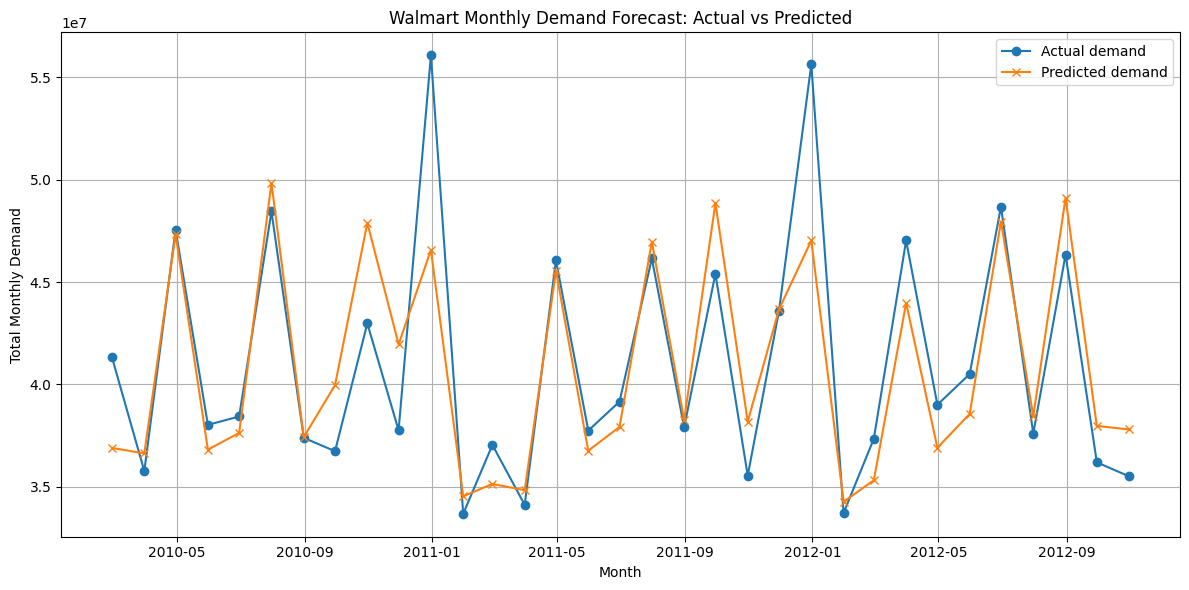

In [16]:
# --- Visualize Monthly Aggregated Actual vs Predicted Demand ---
date_series = df.loc[X_test.index, 'Date']
result_df = pd.DataFrame({
    'Date': pd.to_datetime(date_series),
    'Actual_demand': y_test,
    'Predicted_demand': y_pred
}).sort_values('Date')

# Resample to monthly by summing demand
monthly_df = result_df.set_index('Date').resample('M').sum().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(monthly_df['Date'], monthly_df['Actual_demand'], label='Actual demand', marker='o')
plt.plot(monthly_df['Date'], monthly_df['Predicted_demand'], label='Predicted demand', marker='x')
plt.xlabel("Month")
plt.ylabel("Total Monthly Demand")
plt.title("Walmart Monthly Demand Forecast: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 💡 Optional Enhancements
- Add polynomial features or interaction terms
- Use cross-validation instead of a single split
- Try regularized models like Ridge or Lasso Regression